In [1]:
install.packages("table1")

Installing package into ‘/home/jupyter/.R/library’
(as ‘lib’ is unspecified)



In [2]:
library(bigrquery)
library(knitr)
library(tidyverse)
library(ggplot2)
library("table1")
library("IRdisplay")
library(grid)
library(gridExtra)
bq_auth()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘table1’


The following objects are masked from ‘package:base’:

    units, units<-



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [3]:
data <-bq_dataset_query(query="
SELECT *

 FROM `yhcr-prd-phm-bia-core.CB_1935_AK.src_bmbc_AlevelIMD`"
                       ,x="yhcr-prd-phm-bia-core.CB_1935_AK")

AlevelIMD <- bq_table_download(data) 

In [4]:
data1 <-bq_dataset_query(query="
select round(avg(count1),5)

from(

SELECT person_id,count(person_id) count1

 FROM `yhcr-prd-phm-bia-core.CB_1935_AK.src_bmbc_AlevelIMD`

 group by person_id)base"
                       ,x="yhcr-prd-phm-bia-core.CB_1935_AK")

AlevelIMDavg <- bq_table_download(data1) 

In [5]:
display_jupyter <- function(x) {
  css <- system.file("table1_defaults_1.0/table1_defaults.css", package="table1")
  css <- paste(readLines(css), collapse="\n")
  x <- htmltools::tagList(htmltools::tags$style(css), htmltools::tags$div(class="Rtable1", x))
  IRdisplay::display_html(as.character(x))
}

In [6]:
label(AlevelIMD$AcademicYear)      <- "Academic Year"

label(AlevelIMD$FSMEligible)      <- "Eligible for Free School Meals"
label(AlevelIMD$ethnic_group)      <- "Ethnic Group"
label(AlevelIMD$Gender)      <- "Gender"
label(AlevelIMD$IMD)      <- "Average IMD"

In [7]:
x1 <-table1(~ AlevelIMD$AcademicYear + AlevelIMD$FSMEligible+ AlevelIMD$Gender + AlevelIMD$ethnic_group+ AlevelIMD$IMD|AlevelIMD$ALevelOutcome,data=AlevelIMD
          ,justify=c("left", "left", rep("center", 5)),format_number = TRUE
          ,caption = "COSEY1: Development & Education -1.5 educational attainment.\t Number of students achieving A-Levels A*-B "
    
         )

In [9]:
 display_jupyter(x1)

,1. 3 Or More Alevels at A*-B(N=2837),2. < 3 ALevels A* - B(N=5148),3. 0 ALevels(N=37445),Overall(N=45430)
Academic Year,,,,
2015/2016,710 (25.0%),1367 (26.6%),4380 (11.7%),6457 (14.2%)
2016/2017,736 (25.9%),1302 (25.3%),7770 (20.8%),9808 (21.6%)
2017/2018,696 (24.5%),1215 (23.6%),7696 (20.6%),9607 (21.1%)
2018/2019,695 (24.5%),1264 (24.6%),17599 (47.0%),19558 (43.1%)
Eligible for Free School Meals,,,,
false,2023 (71.3%),3634 (70.6%),10499 (28.0%),16156 (35.6%)
No Data,701 (24.7%),1154 (22.4%),25354 (67.7%),27209 (59.9%)
true,113 (4.0%),360 (7.0%),1592 (4.3%),2065 (4.5%)
Gender,,,,


In [9]:
OverallTrend <- AlevelIMD %>% select(1,4,5)

Alevel_percentage <- OverallTrend %>%
  group_by(AcademicYear,ALevelOutcome) 

ALevel1<- Alevel_percentage %>% count(ALevelOutcome,AcademicYear)


x<- group_by(ALevel1, AcademicYear) %>% mutate(percent = (n/sum(n))*100)


x <-unique(filter(x,ALevelOutcome == "1. 3 Or More Alevels at A*-B"))

x<- group_by(ALevel1, AcademicYear) %>% mutate(percent = (n/sum(n))*100)

x <-unique(filter(x,ALevelOutcome == "1. 3 Or More Alevels at A*-B"))




In [10]:

#x$AcademicYear <- factor(x$AcademicYear), levels = as.character(2012:2023))

OVERALL<- ggplot(x , aes(x = AcademicYear, y = percent,group = 1)) +
#scale_y_continuous( limits=c(0,1))+
  geom_line() +
  geom_point() +
  labs(title = "COS-EY 1: Percentage of students recieving atleast 3 A*-B at Alevel",
       x = "Academic Year",
       y = "Percentage of students per year") +
  theme_minimal()

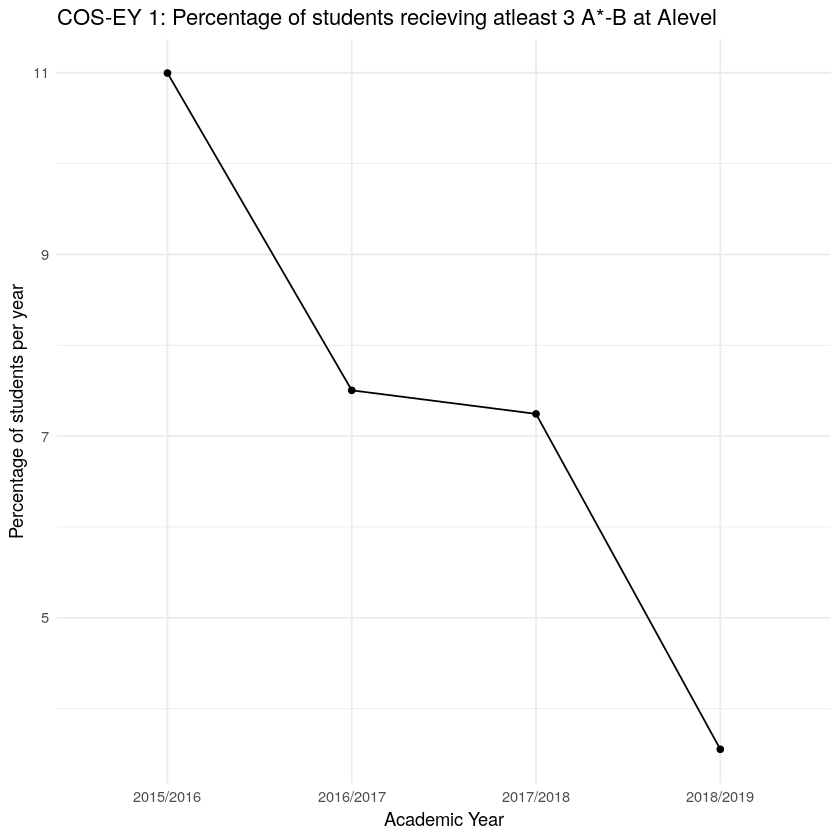

In [11]:
OVERALL

In [142]:
EthnicityTrend <- AlevelIMD %>% select(1,2,4,5)

Alevel_percentageEth <- EthnicityTrend %>%
  group_by(AcademicYear,ALevelOutcome,ethnic_group) 

ALevel1Eth<- Alevel_percentageEth %>%
    count(ALevelOutcome,AcademicYear,ethnic_group)


xEth<- group_by(ALevel1Eth, AcademicYear,ethnic_group) %>% 
mutate(percent = (n/sum(n))*100)


xEth <-unique(filter(xEth,ALevelOutcome == "1. 3 Or More Alevels at A*-B"))

xEth<- group_by(ALevel1Eth, AcademicYear,ethnic_group) %>% mutate(percent = (n/sum(n))*100)

xEth <-unique(filter(xEth,ALevelOutcome == "1. 3 Or More Alevels at A*-B"))




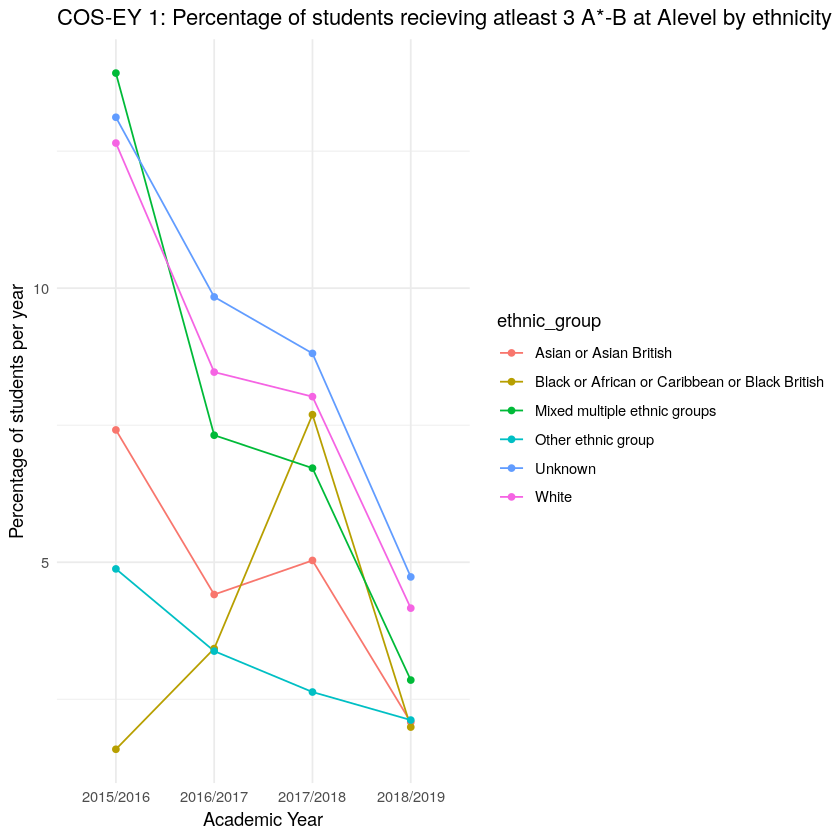

In [151]:
ggplot(xEth , aes(x = AcademicYear, y = percent,group = ethnic_group, color = ethnic_group)) +
#scale_y_continuous( limits=c(0,1))+
  geom_line() +
  geom_point() +
  labs(title = "COS-EY 1: Percentage of students recieving atleast 3 A*-B at Alevel by ethnicity",
       x = "Academic Year",
       y = "Percentage of students per year",
      legend = "Ethnic Group") +
  theme_minimal()

In [155]:
GenderTrend <- AlevelIMD %>% select(1,3,4,5)

Alevel_percentageGender <- GenderTrend %>%
  group_by(AcademicYear,ALevelOutcome,Gender) 

ALevel1Gender<- Alevel_percentageGender %>%
    count(ALevelOutcome,AcademicYear,Gender)


xGender<- group_by(ALevel1Gender, AcademicYear,Gender) %>% 
mutate(percent = (n/sum(n))*100)


xGender <-unique(filter(xGender,ALevelOutcome == "1. 3 Or More Alevels at A*-B"))

xGender<- group_by(ALevel1Gender, AcademicYear,Gender) %>% 
mutate(percent = (n/sum(n))*100)

xGender <-unique(filter(xGender,ALevelOutcome == "1. 3 Or More Alevels at A*-B"))




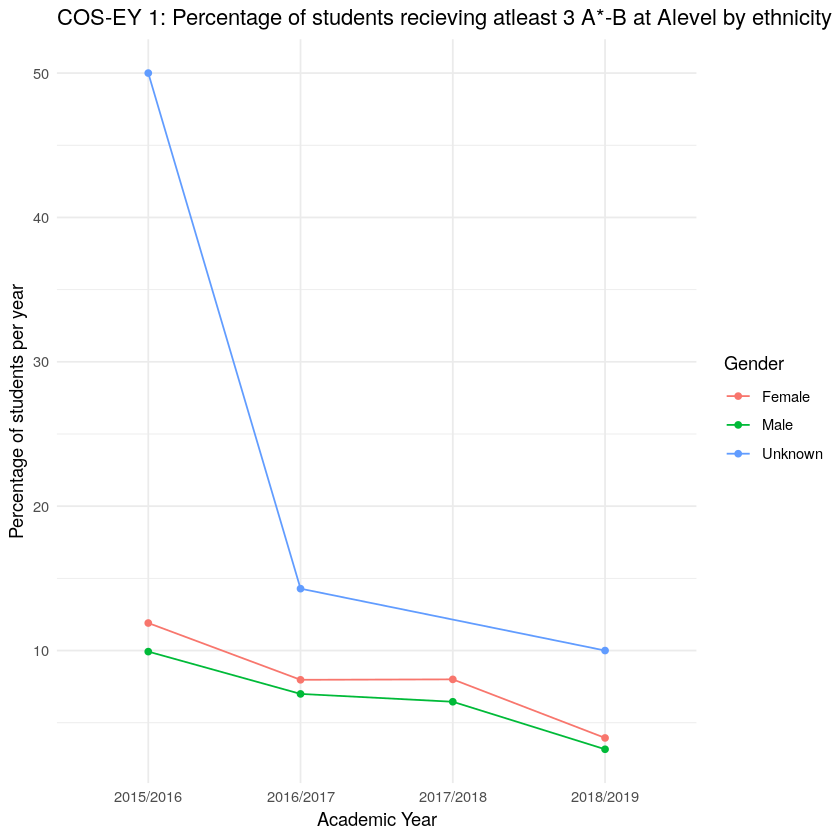

In [156]:
ggplot(xGender , aes(x = AcademicYear, y = percent,group = Gender, color = Gender)) +
#scale_y_continuous( limits=c(0,1))+
  geom_line() +
  geom_point() +
  labs(title = "COS-EY 1: Percentage of students recieving atleast 3 A*-B at Alevel by gender",
       x = "Academic Year",
       y = "Percentage of students per year",
      legend = "Ethnic Group") +
  theme_minimal()

In [158]:
IMDTrend <- AlevelIMD %>% select(1,7,4,5)

Alevel_percentageIMDTrend <- IMDTrend %>%
  group_by(AcademicYear,ALevelOutcome,IMD) 

ALevel1IMDTrend<- Alevel_percentageIMDTrend %>%
    count(ALevelOutcome,AcademicYear,IMD)


xIMDTrend<- group_by(ALevel1IMDTrend, AcademicYear,IMD) %>% 
mutate(percent = (n/sum(n))*100)


xIMDTrend <-unique(filter(xIMDTrend,ALevelOutcome == "1. 3 Or More Alevels at A*-B"))

xIMDTrend<- group_by(ALevel1IMDTrend, AcademicYear,IMD) %>% 
mutate(percent = (n/sum(n))*100)

xIMDTrend<-unique(filter(xIMDTrend,ALevelOutcome == "1. 3 Or More Alevels at A*-B"))




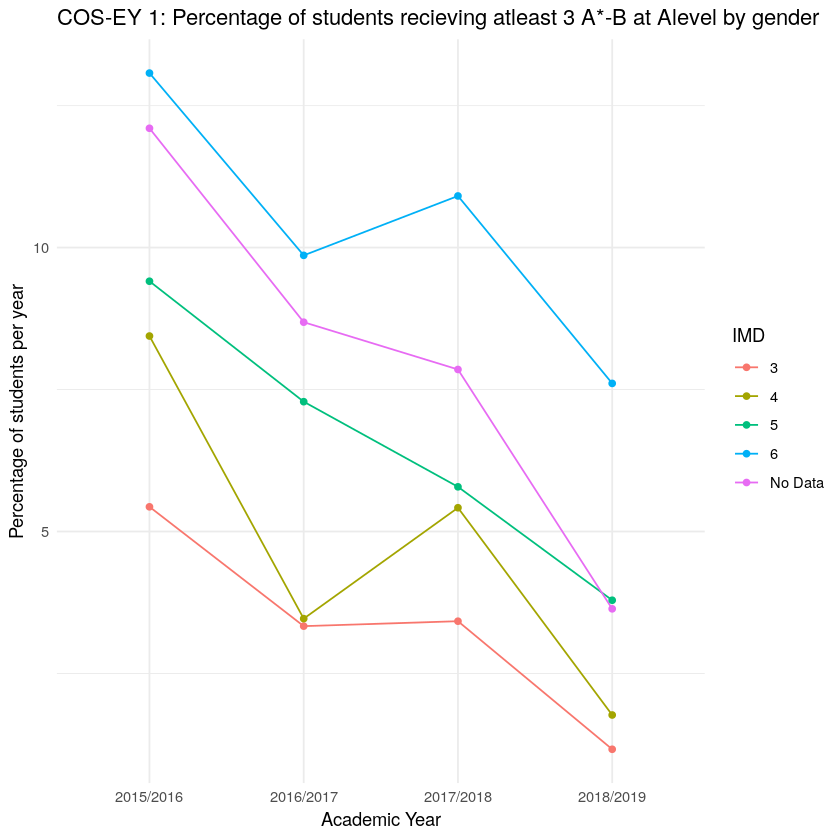

In [159]:
ggplot(xIMDTrend , aes(x = AcademicYear, y = percent,group = IMD, color = IMD)) +
#scale_y_continuous( limits=c(0,1))+
  geom_line() +
  geom_point() +
  labs(title = "COS-EY 1: Percentage of students recieving atleast 3 A*-B at Alevel by IMD",
       x = "Academic Year",
       y = "Percentage of students per year",
      legend = "Ethnic Group") +
  theme_minimal()